## Notebook 5 — LSTM Forecasting
---
One LSTM model per MEV, trained on India + Granger-significant countries.
- Sequence length: 5 years
- Train/test split: last 5 years as holdout
- Output: RMSE + MAE per MEV, predicted vs actual plots, saved models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)

2026-03-04 13:21:48.223632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 13:21:48.258150: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 13:21:49.237842: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0


**Load data and Granger-significant countries**

In [5]:
# Load your cleaned long-format data
df = pd.read_csv('data.csv')

# Melt to long format
df_long = pd.melt(df, id_vars=['COUNTRY', 'INDICATOR', 'FREQUENCY'],
                  var_name='year', value_name='mev_value')
df_long['mev_value'] = pd.to_numeric(df_long['mev_value'], errors='coerce')
df_long['year']      = pd.to_numeric(df_long['year'],      errors='coerce')
df_long = df_long.dropna(subset=['mev_value'])

In [6]:
# Rename indicators — same mapping as Notebook 1
def change_names(row):
    ind = row['INDICATOR']
    if ind == 'Gross domestic product (GDP), Constant prices, Percent change':
        return 'GDP'
    elif ind == 'All Items, Consumer price index (CPI), Period average, percent change':
        return 'Inflation'
    elif ind == 'Current account balance (credit less debit), Percent of GDP':
        return 'Current Balance'
    elif ind == 'Gross national savings, Percent of GDP':
        return 'GNS'
    elif ind == 'Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change':
        return 'Import'
    elif ind == 'Gross capital formation, Percent of GDP':
        return 'Investment'
    elif ind == 'Exports of goods and services, Volume, Free on board (FOB), Percent change':
        return 'Export'
    elif ind == 'Gross debt, General government, Percent of GDP':
        return 'Debt'
    elif ind == 'Structural balance, General government, Percent':
        return 'Fiscal Balance'
    elif ind == 'Unemployment rate':
        return 'Unemployment rate'
    else:
        return 'Other'

df_long['mev_name'] = df_long.apply(change_names, axis=1)
df_long = df_long[df_long['mev_name'] != 'Other']
df_long.head(2)

,COUNTRY,INDICATOR,FREQUENCY,year,mev_value,mev_name
0,United Kingdom,"Current account balance (credit less debit), P...",Annual,2000,-1.831,Current Balance
1,Austria,"Current account balance (credit less debit), P...",Annual,2000,-0.710,Current Balance


In [13]:
# ── Paste your important_countries from Notebook 3 here ──────
# These are the Granger-significant countries for India's GDP
# Update this list based on your actual Granger results
important_countries = ['Bangladesh',
 'Eswatini, Kingdom of',
 'Marshall Islands, Republic of the',
 'Nepal',
 'Nicaragua',
 'Philippines',
 'Puerto Rico',
 'Somalia',
 'Tuvalu']   # ← replace with your output

TARGET_COUNTRY = 'India'
SEQ_LENGTH     = 5
TEST_SIZE      = 5
EPOCHS         = 200
BATCH_SIZE     = 8

ALL_MEVS = [
    'GDP', 'Inflation', 'Unemployment rate', 'Current Balance',
    'Fiscal Balance', 'Debt', 'Investment', 'GNS', 'Export', 'Import'
]

print(f'Target country   : {TARGET_COUNTRY}')
print(f'Granger countries: {important_countries}')
print(f'MEVs to model    : {ALL_MEVS}')

Target country   : India
Granger countries: ['Bangladesh', 'Eswatini, Kingdom of', 'Marshall Islands, Republic of the', 'Nepal', 'Nicaragua', 'Philippines', 'Puerto Rico', 'Somalia', 'Tuvalu']
MEVs to model    : ['GDP', 'Inflation', 'Unemployment rate', 'Current Balance', 'Fiscal Balance', 'Debt', 'Investment', 'GNS', 'Export', 'Import']


**Helper functions**

In [14]:
def make_pivot(df_long, mev):
    """Return (year x country) pivot for a given MEV."""
    subset = df_long[df_long['mev_name'] == mev]
    pivot  = pd.pivot_table(subset, index='year', columns='COUNTRY',
                            values='mev_value', fill_value=np.nan)
    return pivot


def make_sequences(data, seq_length):
    """Sliding window — X shape: (samples, seq_length, features), y shape: (samples,)"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length, :])
        y.append(data[i + seq_length, 0])   # index 0 = India (target)
    return np.array(X), np.array(y)


def build_model(seq_length, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, n_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

**Train one LSTM per MEV**

In [15]:
results  = {}   # stores metrics per MEV
scalers  = {}   # stores fitted scalers
models   = {}   # stores trained models
forecasts = {}  # stores predictions

early_stop = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True, verbose=0)

for mev in ALL_MEVS:
    print(f'\n{"="*50}')
    print(f'Training LSTM for: {mev}')
    print(f'{"="*50}')

    # ── Build pivot ───────────────────────────────────────────
    pivot = make_pivot(df_long, mev)

    # Keep only India + Granger countries that exist in this MEV
    available  = [c for c in [TARGET_COUNTRY] + important_countries if c in pivot.columns]
    pivot      = pivot[available].sort_index()

    # Forward fill then drop any remaining NaNs
    pivot = pivot.ffill().bfill().dropna()

    if len(pivot) < SEQ_LENGTH + TEST_SIZE + 2:
        print(f'  ⚠️  Not enough data for {mev} — skipping')
        continue

    print(f'  Countries used : {available}')
    print(f'  Years available: {pivot.index.min()} — {pivot.index.max()}  ({len(pivot)} rows)')

    # ── Scale ─────────────────────────────────────────────────
    scaler     = MinMaxScaler()
    scaled     = scaler.fit_transform(pivot.values)   # shape: (years, countries)
    scalers[mev] = scaler

    # ── Train / test split ────────────────────────────────────
    train = scaled[:-TEST_SIZE]
    test  = scaled[-TEST_SIZE - SEQ_LENGTH:]   # include lookback for test sequences

    # ── Sequences ─────────────────────────────────────────────
    X_train, y_train = make_sequences(train, SEQ_LENGTH)
    X_test,  y_test  = make_sequences(test,  SEQ_LENGTH)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f'  ⚠️  Sequence generation produced empty arrays — skipping')
        continue

    print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
    print(f'  X_test : {X_test.shape}   y_test : {y_test.shape}')

    # ── Build and train ───────────────────────────────────────
    model = build_model(SEQ_LENGTH, X_train.shape[2])
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    models[mev] = model
    print(f'  Stopped at epoch: {len(history.history["loss"])}')

    # ── Predict ───────────────────────────────────────────────
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()

    # Inverse transform — rebuild full array to invert scaler correctly
    dummy_train = np.zeros((len(y_pred_scaled), scaled.shape[1]))
    dummy_train[:, 0] = y_pred_scaled
    y_pred = scaler.inverse_transform(dummy_train)[:, 0]

    dummy_actual = np.zeros((len(y_test), scaled.shape[1]))
    dummy_actual[:, 0] = y_test
    y_actual = scaler.inverse_transform(dummy_actual)[:, 0]

    forecasts[mev] = {'actual': y_actual, 'predicted': y_pred}

    # ── Metrics ───────────────────────────────────────────────
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae  = mean_absolute_error(y_actual, y_pred)
    results[mev] = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}

    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')


Training LSTM for: GDP
  Countries used : ['India', 'Bangladesh', 'Eswatini, Kingdom of', 'Marshall Islands, Republic of the', 'Nepal', 'Nicaragua', 'Philippines', 'Puerto Rico', 'Somalia', 'Tuvalu']
  Years available: 2000 — 2026  (27 rows)
  X_train: (17, 5, 10)  y_train: (17,)
  X_test : (5, 5, 10)   y_test : (5,)
  Stopped at epoch: 24
  RMSE : 5.1525
  MAE  : 4.9899

Training LSTM for: Inflation
  Countries used : ['India', 'Bangladesh', 'Eswatini, Kingdom of', 'Marshall Islands, Republic of the', 'Nepal', 'Nicaragua', 'Philippines', 'Puerto Rico', 'Somalia', 'Tuvalu']
  Years available: 2000 — 2026  (27 rows)
  X_train: (17, 5, 10)  y_train: (17,)
  X_test : (5, 5, 10)   y_test : (5,)
  Stopped at epoch: 48
  RMSE : 3.0731
  MAE  : 2.6039

Training LSTM for: Unemployment rate
  Countries used : ['India', 'Nicaragua', 'Philippines', 'Puerto Rico']
  Years available: 2000 — 2026  (27 rows)
  X_train: (17, 5, 4)  y_train: (17,)
  X_test : (5, 5, 4)   y_test : (5,)
  Stopped at epoc

**Results summary**

In [16]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print('\nLSTM Results — India:')
print(results_df.to_string())
results_df


LSTM Results — India:
                      RMSE      MAE
Unemployment rate   0.1466   0.1394
Fiscal Balance      1.0640   0.9139
GNS                 2.8009   2.7434
Current Balance     2.9389   2.8868
Inflation           3.0731   2.6039
GDP                 5.1525   4.9899
Investment          5.2590   5.2428
Export              5.4215   4.3176
Debt               13.0734  13.0651
Import             15.6441  15.2731


,RMSE,MAE
Unemployment rate,0.1466,0.1394
Fiscal Balance,1.0640,0.9139
GNS,2.8009,2.7434
Current Balance,2.9389,2.8868
Inflation,3.0731,2.6039
GDP,5.1525,4.9899
Investment,5.2590,5.2428
Export,5.4215,4.3176
Debt,13.0734,13.0651
Import,15.6441,15.2731


**Predicted vs Actual plots**

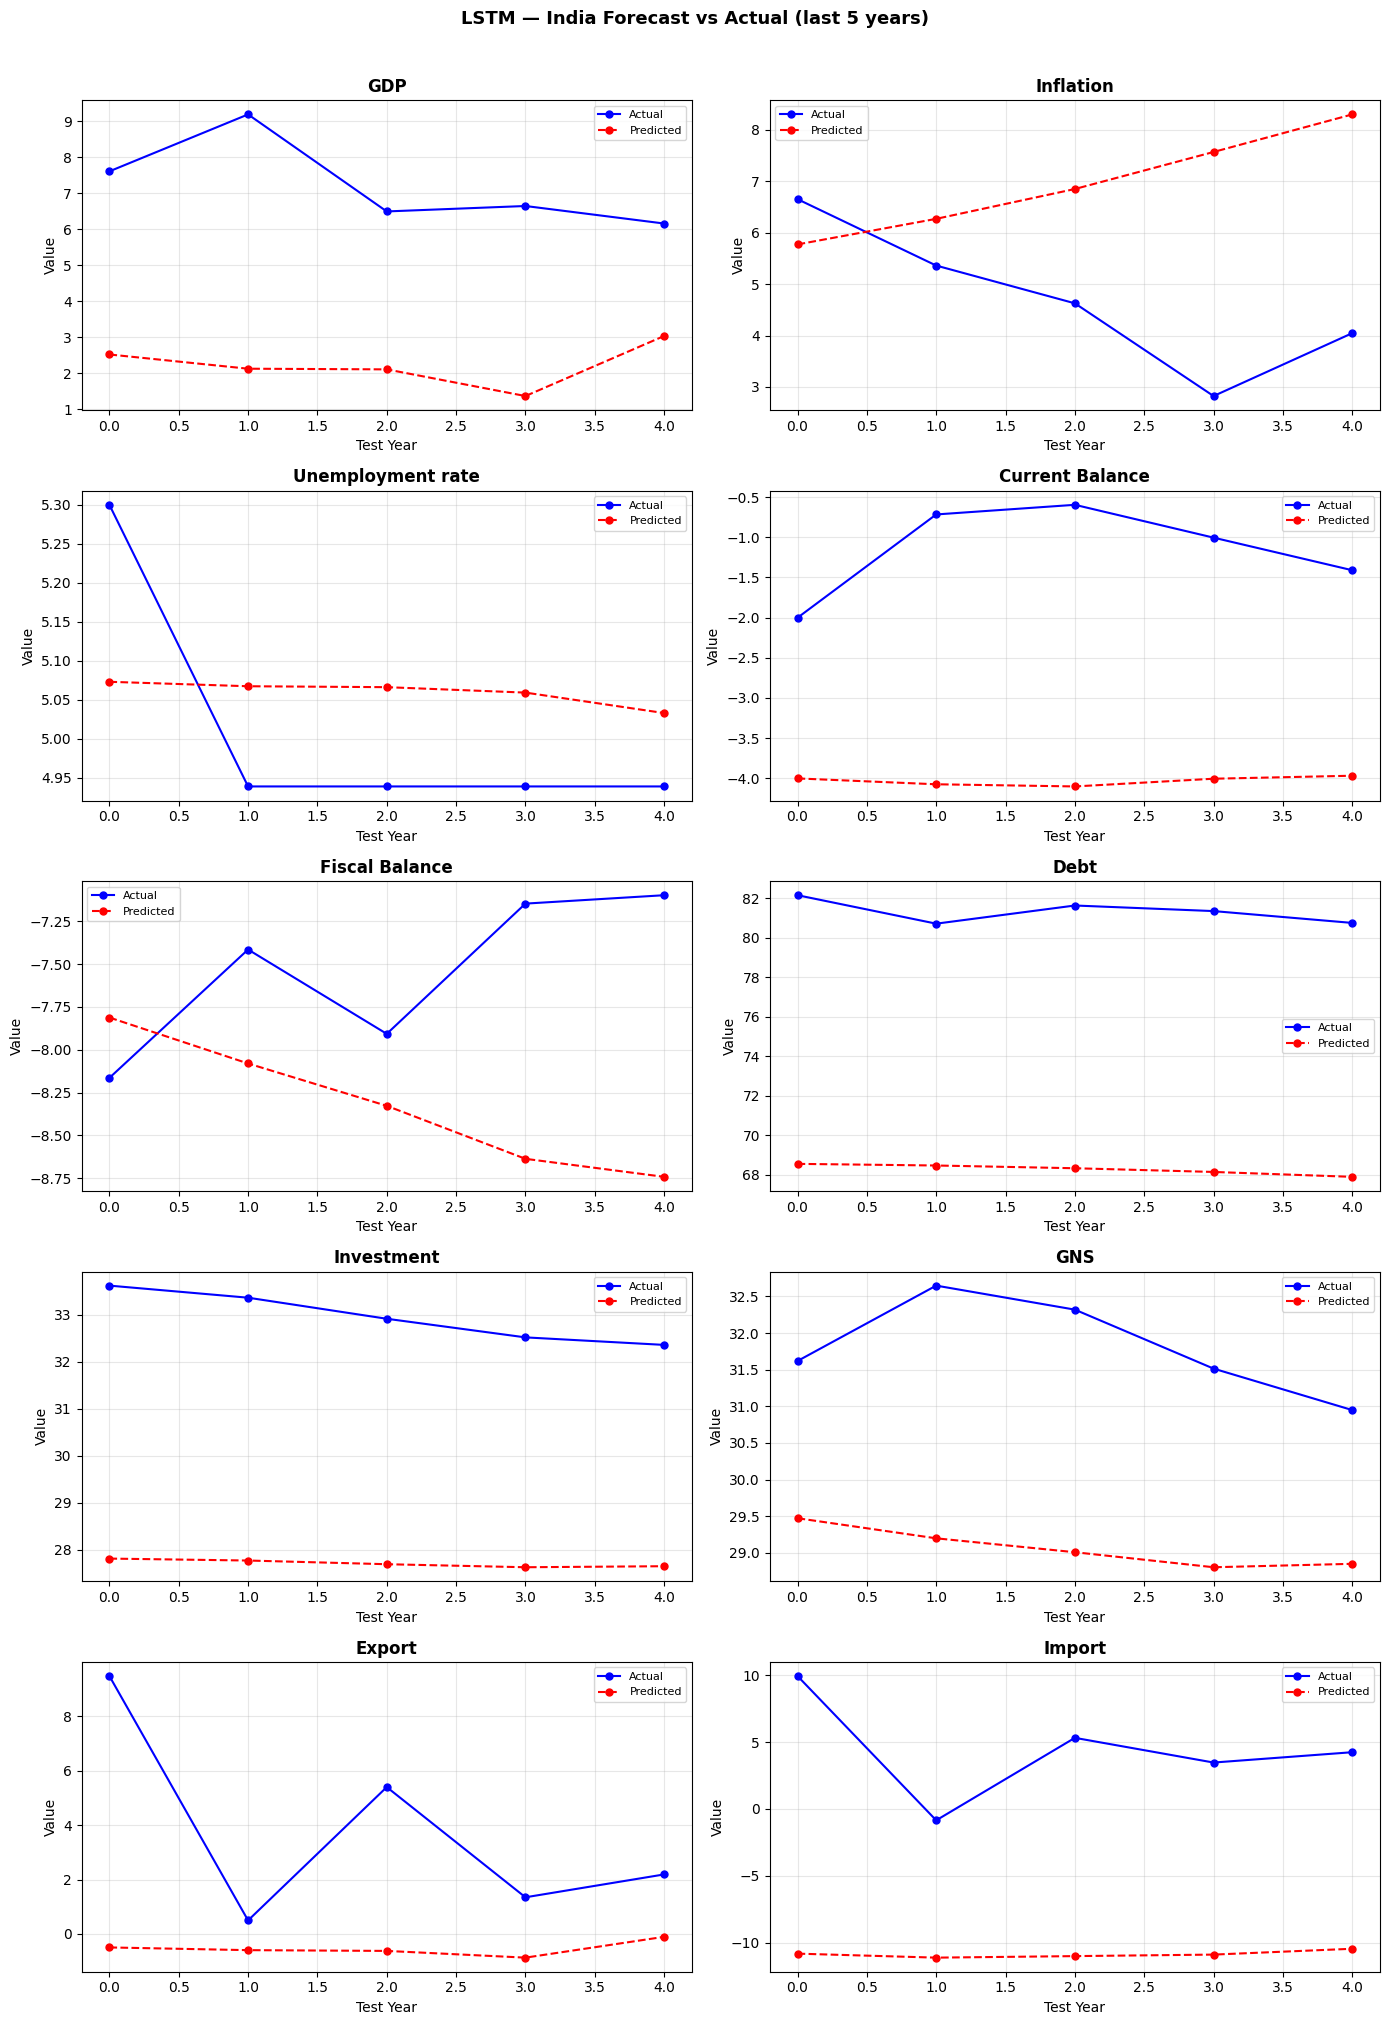

In [17]:
n_mevs    = len(forecasts)
n_cols    = 2
n_rows    = n_mevs // n_cols + n_mevs % n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes      = np.array(axes).flatten()

for idx, (mev, vals) in enumerate(forecasts.items()):
    ax = axes[idx]
    ax.plot(vals['actual'],    'b-o', label='Actual',    markersize=5)
    ax.plot(vals['predicted'], 'r--o', label='Predicted', markersize=5)
    ax.set_title(f'{mev}', fontweight='bold')
    ax.set_xlabel('Test Year')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(forecasts), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'LSTM — India Forecast vs Actual (last {TEST_SIZE} years)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

**Save models and scalers**

In [18]:
import os
os.makedirs('lstm_models', exist_ok=True)

for mev, model in models.items():
    safe_name = mev.replace(' ', '_')
    model.save(f'lstm_models/{safe_name}.keras')
    print(f'Saved model : lstm_models/{safe_name}.keras')

with open('lstm_models/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print('Saved scalers: lstm_models/scalers.pkl')

with open('lstm_models/results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Saved results: lstm_models/results.pkl')

with open('lstm_models/forecasts.pkl', 'wb') as f:
    pickle.dump(forecasts, f)
print('Saved forecasts: lstm_models/forecasts.pkl')

Saved model : lstm_models/GDP.keras
Saved model : lstm_models/Inflation.keras
Saved model : lstm_models/Unemployment_rate.keras
Saved model : lstm_models/Current_Balance.keras
Saved model : lstm_models/Fiscal_Balance.keras
Saved model : lstm_models/Debt.keras
Saved model : lstm_models/Investment.keras
Saved model : lstm_models/GNS.keras
Saved model : lstm_models/Export.keras
Saved model : lstm_models/Import.keras
Saved scalers: lstm_models/scalers.pkl
Saved results: lstm_models/results.pkl
Saved forecasts: lstm_models/forecasts.pkl


# End